In [1]:
%pip install ultralytics
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications.resnet50 import preprocess_input
from ultralytics import YOLO
import os
from IPython.display import Image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 21.9 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 74.1 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you

2026-06-29 20:04:17.935073: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782763458.149465      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782763458.213057      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782763458.757446      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782763458.757487      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782763458.757490      58 computation_placer.cc:177] computation placer alr

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("fatihkgg/affectnet-yolo-format")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format


In [4]:
train_images_path = os.path.join(path, 'YOLO_format', 'train', 'images')
image_files = os.listdir(train_images_path)

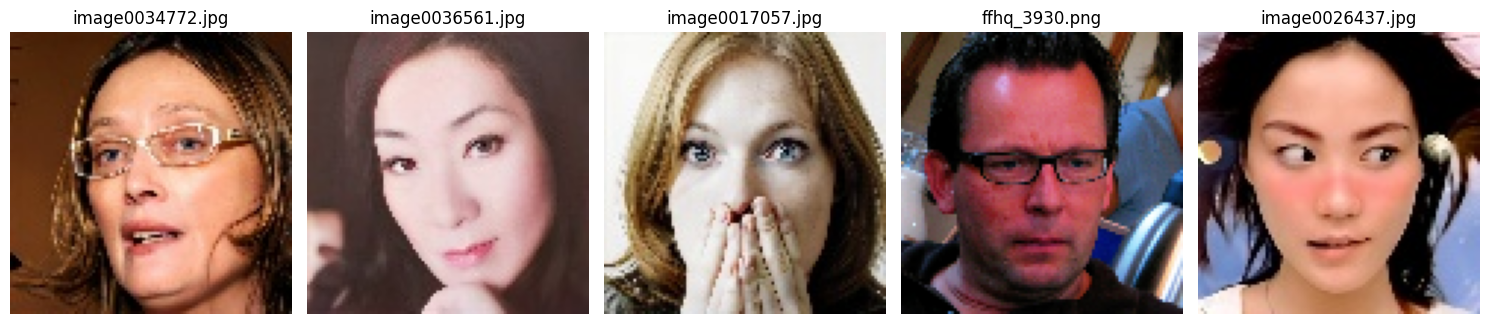

In [5]:
import random
import matplotlib.pyplot as plt
import cv2

random_images = random.sample(image_files, 5)
plt.figure(figsize=(15, 5))

for i, img_file in enumerate(random_images):
    img_path = os.path.join(train_images_path, img_file)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(1, 5, i + 1)
    plt.imshow(img)
    plt.title(img_file)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [6]:
yaml_content = """
path: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format
train: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/train
val: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid
test: /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test

nc: 8
names: [ "Anger",
    "Contempt",
    "Disgust",
    "Fear",
    "Happy",
    "Neutral",
    "Sad",
    "Surprise",]
"""
with open("affectnet.yaml", "w") as f:
    f.write(yaml_content)

In [7]:
model = YOLO('yolov8n.pt')
print("YOLO model 'yolov8n.pt' installed")
results = model.train(
    data="affectnet.yaml",
    epochs=80,
    imgsz=640,
    batch=32,
    project='affectnet_yolo_training',
    name="train",
    exist_ok=True
)

YOLO model 'yolov8n.pt' installed
Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=affectnet.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=80, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_m

In [9]:
from ultralytics import YOLO

model = YOLO(
    "runs/detect/affectnet_yolo_training/train/weights/best.pt"
)

model.train(
    data="affectnet.yaml",
    epochs=25,
    lr0=1e-4,
    batch=32,
    imgsz=640
)

New https://pypi.org/project/ultralytics/8.4.83 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=affectnet.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/affectnet_yolo_training/train/weights/best.pt, momentum=0.9

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ea7524e3830>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

In [10]:
from ultralytics import YOLO

model = YOLO("runs/detect/affectnet_yolo_training/train/weights/best.pt")
metrics = model.val(data="affectnet.yaml", split="val")

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
Model summary (fused): 73 layers, 3,007,208 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 22.6±16.9 MB/s, size: 11.1 KB)
val: Scanning /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid/labels... 5406 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5406/5406 1.2Kit/s 4.4s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/valid is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 338/338 8.4it/s 40.4s0.1ss
                   all       5406       5406      0.725       0.78       0.83       0.83
                 Anger        712        712      0.693      0.794       0.83       0.83
              Contempt        618        618      0.723      0.804      0.855      0.855
               Disgust        672  

In [12]:
metrics = model.val(data="affectnet.yaml", split="test")

print("Precision:", metrics.box.mp)
print("Recall:", metrics.box.mr)
print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.82 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
val: Fast image access ✅ (ping: 0.3±0.2 ms, read: 2.2±1.5 MB/s, size: 12.4 KB)
val: Scanning /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test/labels... 2755 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2755/2755 201.7it/s 13.7s0.0s
WARNING ⚠️ val: Cache directory /kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test is not writable, cache not saved.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 173/173 8.0it/s 21.6s0.1s
                   all       2755       2755      0.716      0.798      0.834      0.834
                 Anger        383        383      0.714       0.83      0.842      0.842
              Contempt        332        332      0.683      0.798      0.809      0.809
               Disgust        327        327      0.707      0.737      0.798      0.798
                  Fear       


0: 640x640 1 Sad, 9.8ms
Speed: 2.9ms preprocess, 9.8ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


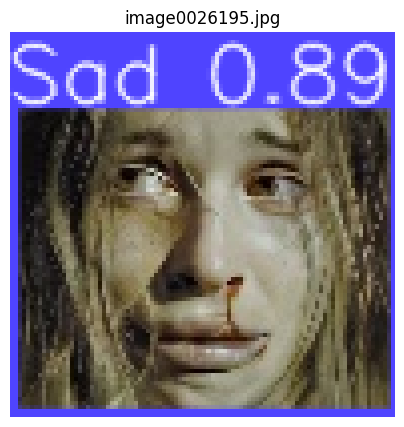


0: 640x640 1 Anger, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


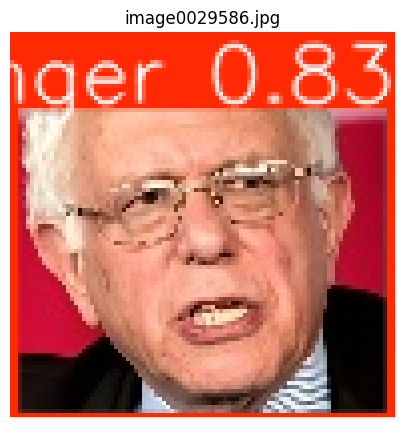


0: 640x640 1 Contempt, 7.3ms
Speed: 2.0ms preprocess, 7.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


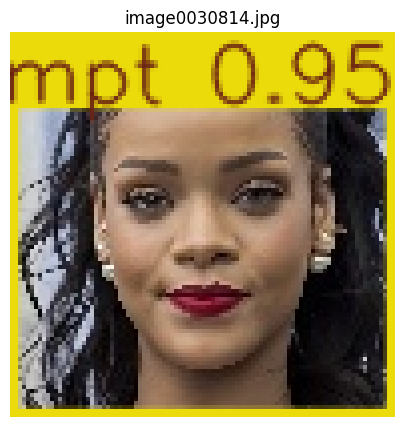


0: 640x640 1 Neutral, 7.2ms
Speed: 1.9ms preprocess, 7.2ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)


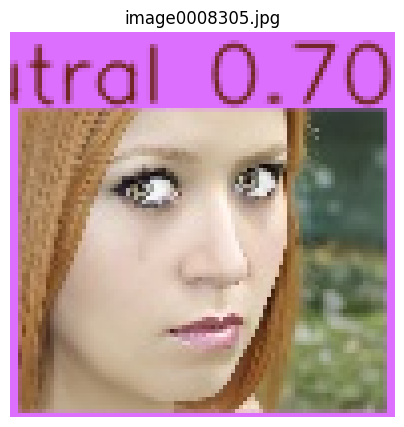


0: 640x640 1 Contempt, 1 Happy, 7.2ms
Speed: 2.2ms preprocess, 7.2ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


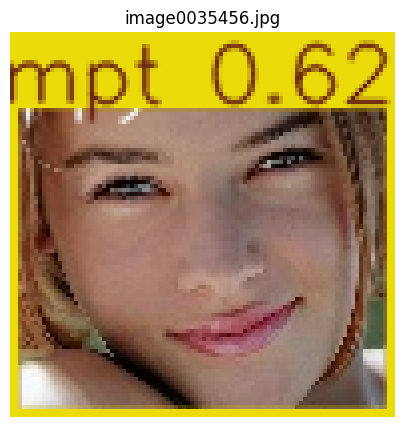

In [20]:
import random
import glob
import cv2
import matplotlib.pyplot as plt

test_images = glob.glob("/kaggle/input/datasets/fatihkgg/affectnet-yolo-format/YOLO_format/test/images/*.jpg")

samples = random.sample(test_images, 5)

for img_path in samples:
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img_rgb)

    annotated = results[0].plot()

    plt.figure(figsize=(5,5))
    plt.imshow(annotated)
    plt.axis("off")
    plt.title(img_path.split("/")[-1])
    plt.show()